# MLP Pion Classifier: Summary Statistics

Baseline MLP on four track-level summary stats. Acts as the
contemporary-method reference for the hit-level CNN and hybrid models.

- `chi²/ndof_proton`
- `track_length` (cm)
- `track_score` (Pandora track quality score)
- `dEdX_median`

## Setup

In [ ]:
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from utils.general_utils import (PROJECT_ROOT, SPECIES_COLORS, SPECIES_ALL,
                                 species_label, target_config,
                                 purity, efficiency, create_confusion_matrix)
from utils.evaluation_utils import (
    optimise_threshold,
    plot_roc_and_purity_efficiency,
    save_results,
    plot_training_curves,
    combine_pdfs,
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

TARGET = "photon"          # "pion" | "photon"
cfg    = target_config(TARGET)
BASE   = "mlp_summary"

PREPARED_DIR      = PROJECT_ROOT / "prepared" / "prepared-mc"
PREPARED_DATA_DIR = PROJECT_ROOT / "prepared" / "prepared-data"
PRED_MC_DIR       = PROJECT_ROOT / "predictions" / "predictions-mc"
PRED_DATA_DIR     = PROJECT_ROOT / "predictions" / "predictions-data"
MODELS_DIR        = PROJECT_ROOT / "models"
RESULTS_PATH   = PRED_MC_DIR   / f"{BASE}{cfg['suffix']}.pkl"
MODEL_PATH     = MODELS_DIR    / f"{BASE}{cfg['suffix']}.pt"
DATA_PRED_PATH = PRED_DATA_DIR / f"mlp_data_predictions{cfg['suffix']}.pkl"
PLOTS_DIR = PROJECT_ROOT / "plots" / "mlp-classifier" / TARGET
for d in (PRED_MC_DIR, PRED_DATA_DIR, MODELS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"target: {TARGET}  ->  {RESULTS_PATH.name}, {MODEL_PATH.name}")

Using device: cpu
target: photon  ->  mlp_summary_photon.pkl, mlp_summary_photon.pt


## Data Loading

In [5]:
data_size = "all"  # or "50000"
all_summary_stats = True

with open(PREPARED_DIR / f"train_{data_size}.pkl", "rb") as f:
    train = pickle.load(f)
with open(PREPARED_DIR / "test.pkl", "rb") as f:
    test = pickle.load(f)

y_train = train[f"labels_{TARGET}"].astype(np.int64)   # MLP/CNN use int64
y_test  = test[f"labels_{TARGET}"].astype(np.int64)

cols = slice(None) if all_summary_stats else [1, 3]  # track_length, dEdX_median
summ_train = train["summary"][:, cols] if not all_summary_stats else train["summary"]
summ_test  = test["summary"][:,  cols] if not all_summary_stats else test["summary"]
n_features = summ_train.shape[1]

print(f"Train: {int(y_train.sum()):,} {TARGET}s / {len(y_train):,} ({100*y_train.mean():.1f}%)")
print(f"Test:  {int(y_test.sum()):,} {TARGET}s / {len(y_test):,} ({100*y_test.mean():.1f}%)")
print(f"summary: {summ_train.shape}")

Train: 77,950 photons / 507,265 (15.4%)
Test:  19,753 photons / 126,817 (15.6%)
summary: (507265, 4)


## Dataset & DataLoader

In [3]:
class SummaryDataset(Dataset):
    def __init__(self, summary, labels):
        self.summary = torch.FloatTensor(summary)
        self.labels  = torch.FloatTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.summary[idx], self.labels[idx]


train_ds = SummaryDataset(summ_train, y_train)
test_ds  = SummaryDataset(summ_test,  y_test)

w = (1.0 / np.bincount(y_train))[y_train]
sampler = WeightedRandomSampler(w, num_samples=len(w), replacement=True)

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

NameError: name 'summ_train' is not defined

## Model Definition

In [6]:
class MLPClassifier(nn.Module):
    def __init__(self, n_features=4, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16),         nn.BatchNorm1d(16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


model = MLPClassifier(n_features=n_features).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 801


## Training

In [ ]:
criterion = FocalLoss(gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

N_EPOCHS = 80
EARLY_STOP_PATIENCE = 15


def train_epoch():
    model.train()
    total, n = 0.0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
        n += len(y)
    return total / n


def evaluate(loader, threshold=0.5):
    model.eval()
    total, n = 0.0, 0
    probs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total += criterion(logits, y).item() * len(y)
            n += len(y)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            ys.extend(y.cpu().numpy().astype(int))
    probs, ys = np.array(probs), np.array(ys)
    preds = (probs >= threshold).astype(int)
    return total / n, purity(preds, ys, [1], [1]), efficiency(preds, ys, [1], [1]), probs, ys


history = {'train_loss': [], 'val_loss': [], 'purity': [], 'efficiency': []}
best_val = float('inf')
patience = 0
best_state = None

for epoch in range(N_EPOCHS):
    train_loss = train_epoch()
    val_loss, val_pur, val_eff, _, _ = evaluate(test_loader)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['purity'].append(val_pur)
    history['efficiency'].append(val_eff)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Purity: {100*val_pur:.1f}% | Efficiency: {100*val_eff:.1f}%")

    if val_loss < best_val:
        best_val = val_loss
        patience = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)
print(f"\nBest validation loss: {best_val:.4f}")

Epoch   1 | Train Loss: 0.1125 | Val Loss: 0.1056 | Val Purity: 41.5% | Val Efficiency: 92.4%
Epoch  10 | Train Loss: 0.0968 | Val Loss: 0.1074 | Val Purity: 41.6% | Val Efficiency: 92.8%
Epoch  20 | Train Loss: 0.0966 | Val Loss: 0.1099 | Val Purity: 41.0% | Val Efficiency: 93.5%
Epoch  30 | Train Loss: 0.0963 | Val Loss: 0.1088 | Val Purity: 41.7% | Val Efficiency: 92.5%
Early stopping at epoch 39

Best validation loss: 0.0977


## Training Curves

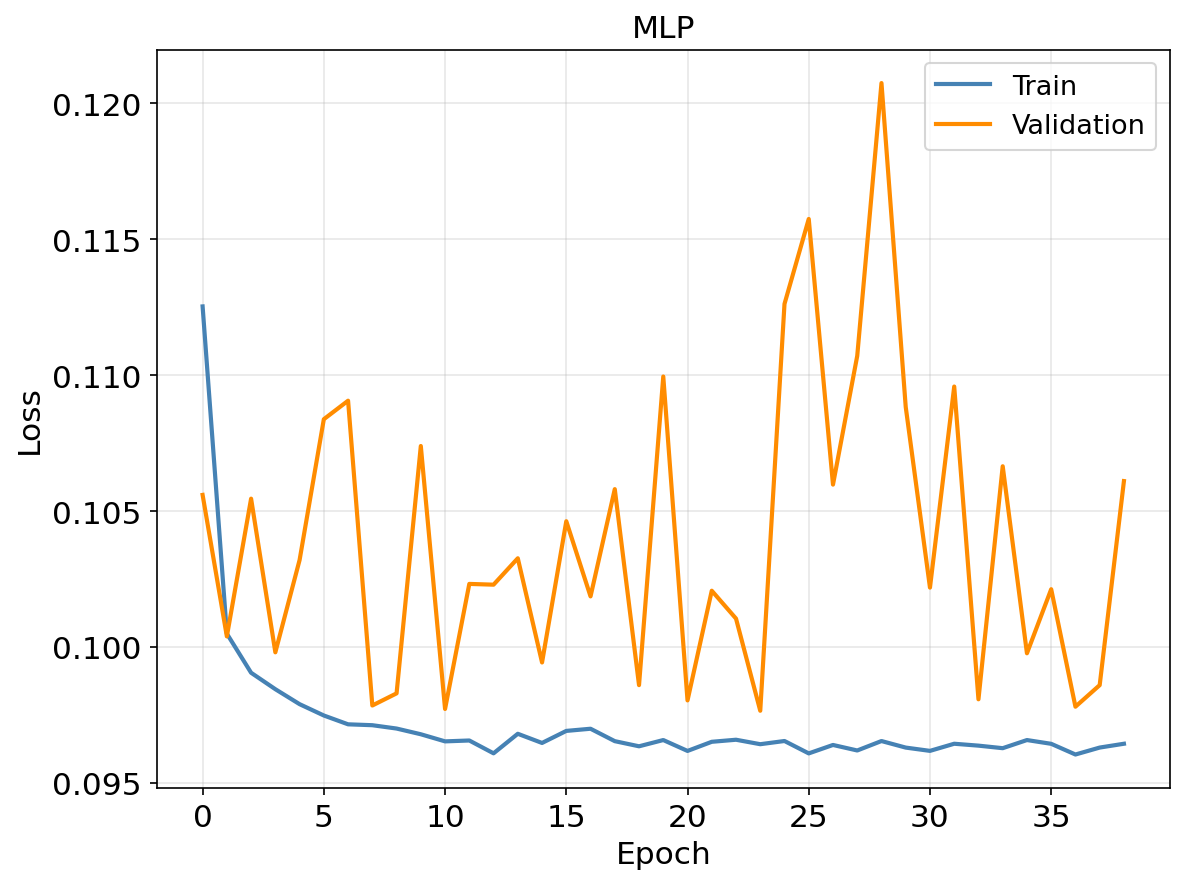

In [ ]:
plot_training_curves(history, f'{BASE} ({TARGET})',
                     save_path=PLOTS_DIR / f"training_{TARGET}.pdf")

## Threshold Optimisation & Final Evaluation

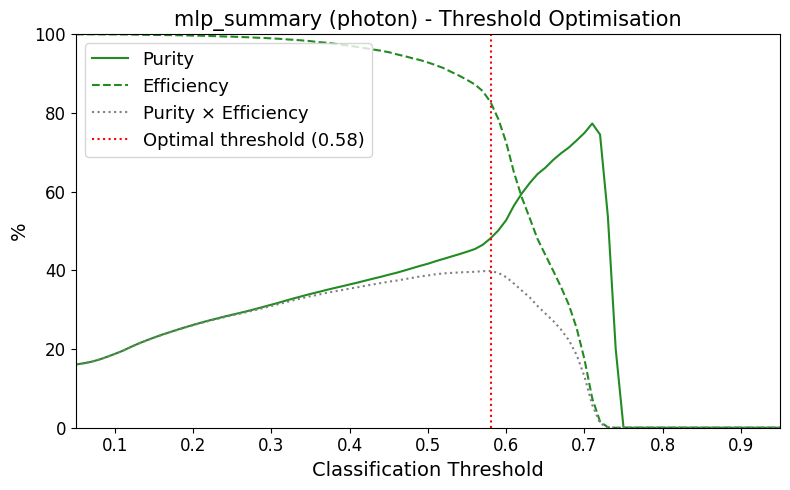

=== mlp_summary (photon) (threshold=0.58) ===
  AUC:        0.914
  Purity:     48.1% ± 0.3%
  Efficiency: 82.8% ± 0.3%
  Product:    39.8%
Saved to /home/pemb7173/PDSP-pion-classification/predictions/predictions-mc/mlp_summary_photon.pkl
Saved /home/pemb7173/PDSP-pion-classification/models/mlp_summary_photon.pt


In [ ]:
_, _, _, test_probs, test_labels = evaluate(test_loader)
best_threshold = optimise_threshold(
    test_probs, test_labels, label=f'{BASE} ({TARGET})', color='forestgreen',
    save_path=PLOTS_DIR / f"threshold_{TARGET}.pdf")
final_preds = (test_probs >= best_threshold).astype(int)

save_results(
    test_probs, test_labels, best_threshold,
    model_name=f"{BASE} -- {TARGET} target",
    save_path=RESULTS_PATH,
)

torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved {MODEL_PATH}")

## ROC Curve

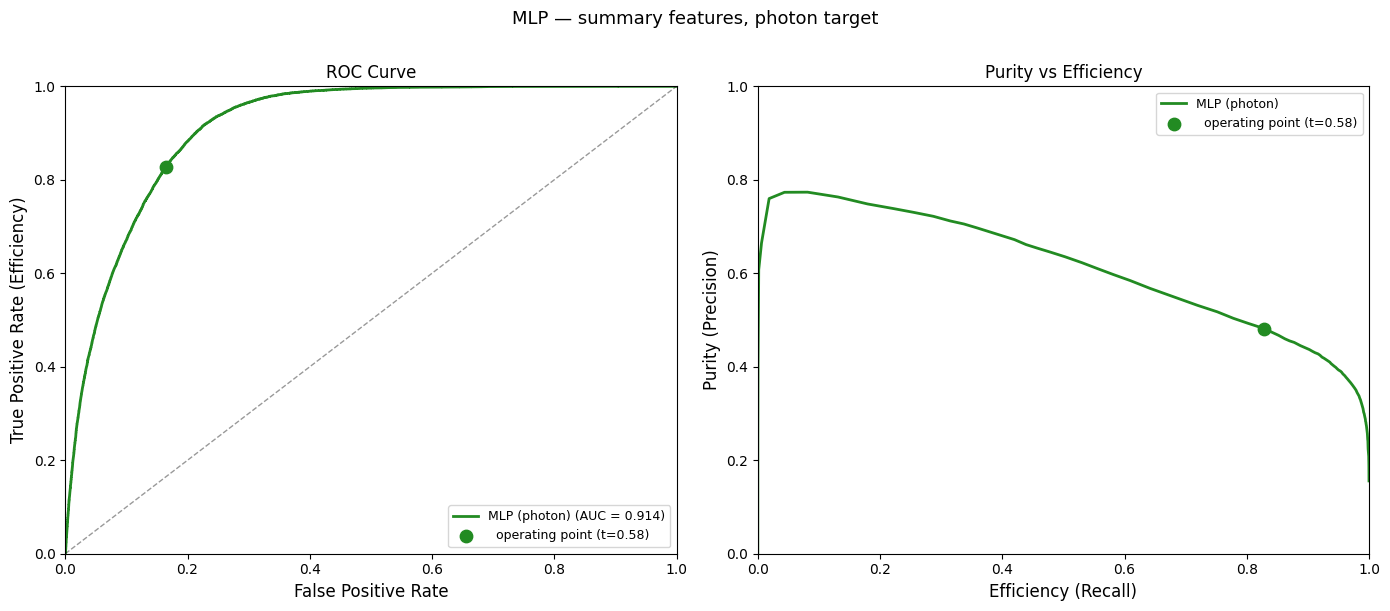

In [ ]:
plot_roc_and_purity_efficiency(
    [{'probs': test_probs, 'labels': test_labels, 'threshold': best_threshold,
      'color': 'forestgreen', 'label': f'MLP ({TARGET})'}],
    title=f'MLP — {cfg["signal_name"]}',
    save_path=PLOTS_DIR / f"roc_{TARGET}.pdf",
)

## Confusion Matrix

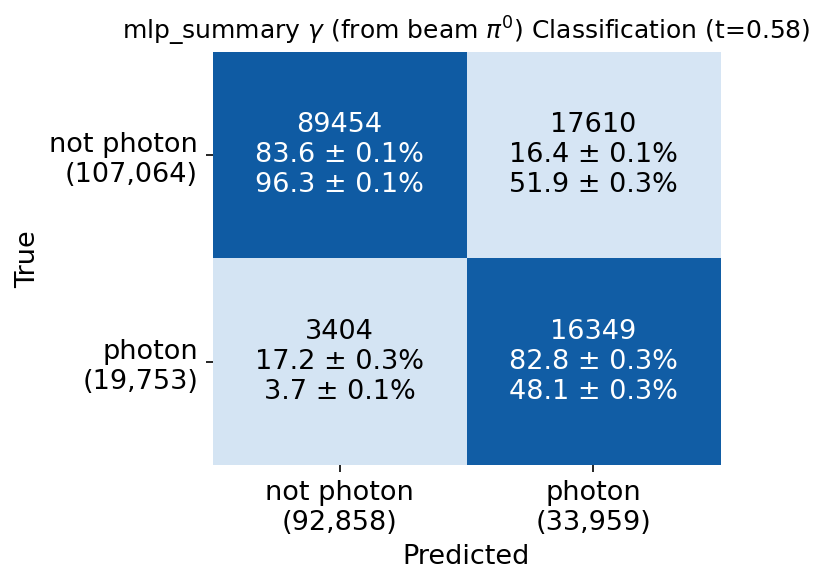

In [ ]:
def plot_cm_heatmap(labels, preds, threshold, title='π± Classification', figsize=(5, 4)):
    cm, info, raw_names = create_confusion_matrix(labels, preds)
    cm, info = cm[::-1], info[::-1]

    # cells come as count/purity/efficiency; swap last two
    def _swap(s):
        a, b, c = s.split('\n')
        return f'{a}\n{c}\n{b}'
    info = np.vectorize(_swap)(info)

    names = [{'0': f'not {TARGET}', '1': TARGET}.get(n, n) for n in raw_names]
    col_totals = cm.sum(axis=0)
    row_totals = cm.sum(axis=1)
    row_norm = cm / row_totals[:, None].clip(min=1)

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.imshow(row_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            c = 'white' if row_norm[i, j] > 0.6 else 'black'
            ax.text(j, i, info[i][j], ha='center', va='center', fontsize=13, color=c)

    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels([f'{names[j]}\n({col_totals[j]:,})' for j in range(len(names))], fontsize=13)
    ax.set_yticklabels([f'{names[i]}\n({row_totals[i]:,})' for i in range(len(names))], fontsize=13)
    ax.set_xlabel('Predicted', fontsize=13)
    ax.set_ylabel('True', fontsize=13)
    ax.set_title(f'{title} (t={threshold:.2f})', fontsize=12)
    ax.spines[:].set_visible(False)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"confusion_{TARGET}.pdf", bbox_inches='tight')
    plt.show()


plot_cm_heatmap(test_labels, final_preds, best_threshold,
                title=f"{BASE} {cfg['signal_name']} Classification")

In [7]:
with open(PREPARED_DIR / "test_tracks.pkl", "rb") as f:
    test_tracks = pickle.load(f)

In [8]:
# Skip retraining: reload the saved evaluation + trained weights
# requires: setup cell + the MLPClassifier class definition and n_features (from the data-loading cell)
with open(RESULTS_PATH, "rb") as f:
    saved = pickle.load(f)

test_probs, test_labels, best_threshold = saved["probs"], saved["labels"], saved["threshold"]
final_preds = (test_probs >= best_threshold).astype(int)

model = MLPClassifier(n_features=n_features).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

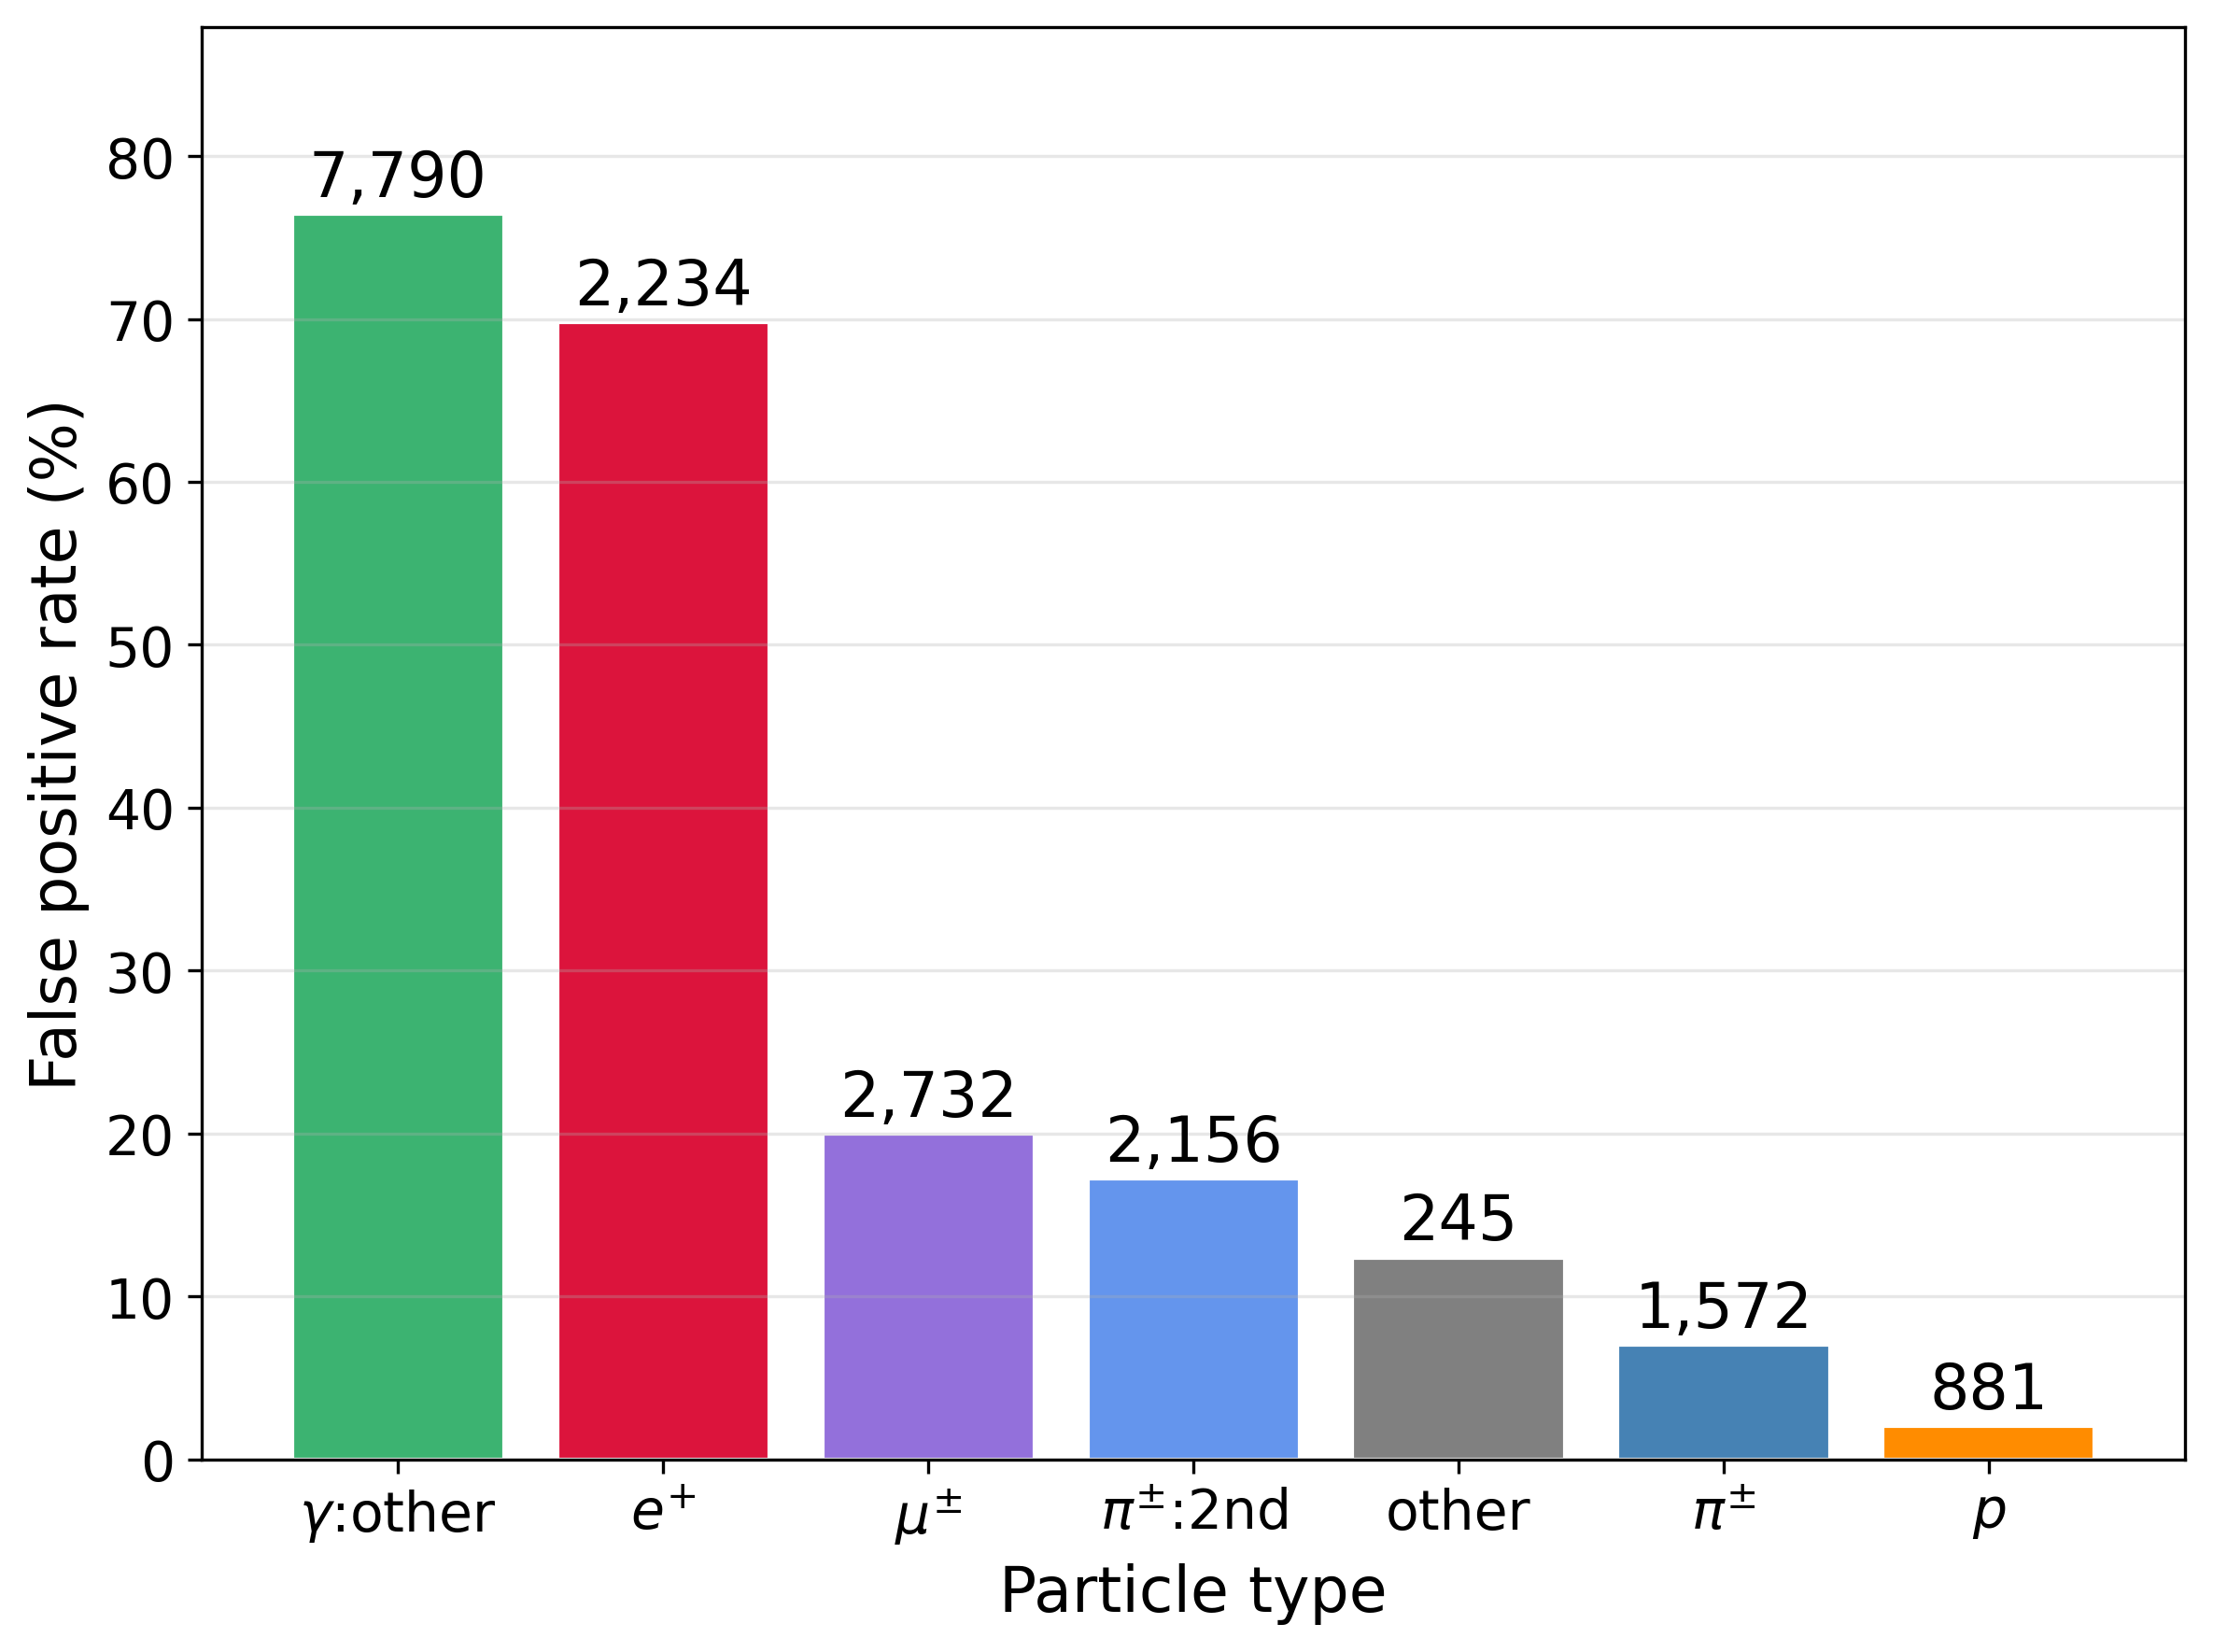

In [ ]:
# requires: setup, test_tracks loaded (cell above), and final_preds/test_labels (from training or "skip retraining")
fp_mask = (final_preds == 1) & (test_labels == 0)
fp_counts    = Counter(species_label(test_tracks[i]) for i in np.where(fp_mask)[0])
total_counts = Counter(species_label(test_tracks[i]) for i in np.where(test_labels == 0)[0])

classes = sorted(total_counts, key=lambda c: -fp_counts.get(c, 0) / total_counts[c])
rates   = [100 * fp_counts.get(c, 0) / total_counts[c] for c in classes]
cols    = [SPECIES_COLORS.get(c, 'grey') for c in classes]

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
bars = ax.bar(range(len(classes)), rates, color=cols, edgecolor='white')
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, fontsize=16)
ax.set_ylabel('False positive rate (%)', fontsize=16)
ax.set_xlabel('Particle type', fontsize=16)
ax.tick_params(labelsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, max(rates) * 1.15)
for bar, c in zip(bars, classes):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{fp_counts.get(c, 0):,}', ha='center', va='bottom', fontsize=16)
plt.tight_layout()
plt.savefig(PLOTS_DIR / f"fp_by_species_{TARGET}.pdf", bbox_inches='tight')
plt.show()

## Run Trained MLP on Real Data

In [14]:
# ===== Run trained MLP on REAL DATA =====
# requires: setup + a trained model in memory (via training OR "skip retraining" cell) + best_threshold
with open(PREPARED_DATA_DIR / "data_inference.pkl", "rb") as f:
    d = pickle.load(f)
summ_data = d["summary"]
evt, pid = d["event_number"], d["PFO_ID"]
print(f"Data PFOs: {len(pid):,}")

model.eval()
X = torch.FloatTensor(summ_data).to(device)
probs = []
with torch.no_grad():
    for i in range(0, len(X), 4096):
        probs.append(torch.sigmoid(model(X[i:i+4096])).cpu().numpy())
data_probs = np.concatenate(probs)
data_preds = (data_probs >= best_threshold).astype(int)
print(f"{BASE} data ({TARGET}): {data_preds.sum():,} / {len(data_preds):,} "
      f"({100*data_preds.mean():.1f}%)  (threshold={best_threshold:.3f})")

with open(DATA_PRED_PATH, "wb") as f:
    pickle.dump({"probs": data_probs, "preds": data_preds, "threshold": best_threshold,
                 "event_number": evt, "PFO_ID": pid,
                 "model_name": f"{BASE} ({TARGET})"}, f)
print(f"Saved {DATA_PRED_PATH}")

Data PFOs: 353,652
mlp_summary data (photon): 107,338 / 353,652 (30.4%)  (threshold=0.580)
Saved /home/pemb7173/PDSP-pion-classification/predictions/predictions-data/mlp_data_predictions_photon.pkl
